## Cell 1: Cài đặt và import thư viện

In [5]:
!pip install -q thop

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from thop import profile

## Cell 2: Cấu hình chung

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Giữ nguyên đường dẫn dataset trên Kaggle
DATA_ROOT = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.15

MODEL_NAME = "resnet18"
PRETRAINED = True
SAVE_PATH = "/kaggle/working/resnet18_brain_tumor_best.pth"

Device: cuda
Train dir exists: True
Test dir exists: True


## Cell 3: Transform ảnh

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Cell 4: Load dataset và chia train/validation

In [8]:
full_train_dataset_aug = ImageFolder(root=TRAIN_DIR, transform=train_transform)
full_train_dataset_eval = ImageFolder(root=TRAIN_DIR, transform=val_test_transform)
test_dataset = ImageFolder(root=TEST_DIR, transform=val_test_transform)

class_names = full_train_dataset_aug.classes
print("Classes:", class_names)
print("Class to index:", full_train_dataset_aug.class_to_idx)

train_size = int((1 - VAL_RATIO) * len(full_train_dataset_aug))
val_size = len(full_train_dataset_aug) - train_size

# Tạo cùng một bộ indices để train subset dùng augmentation, val subset không dùng augmentation
all_indices = torch.randperm(len(full_train_dataset_aug), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:]

from torch.utils.data import Subset
train_dataset = Subset(full_train_dataset_aug, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 4760
Val size: 840
Test size: 1600


## Cell 5: Tạo DataLoader

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Cell 6: Kiểm tra số lượng ảnh mỗi lớp

In [10]:
def count_images_per_class(dataset_path):
    counts = {}
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ])
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Training set:")
print(train_counts)

print("\nTesting set:")
print(test_counts)

Training set:
{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}

Testing set:
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


## Cell 7: Khởi tạo model ResNet-18

In [11]:
def create_resnet18(num_classes=4, pretrained=True):
    if pretrained:
        try:
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            model = models.resnet18(weights=weights)
            print("Loaded ImageNet pretrained weights.")
        except Exception as e:
            print("Could not load pretrained weights. Using random initialization.")
            print("Error:", e)
            model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=None)
        print("Using random initialization.")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = create_resnet18(num_classes=NUM_CLASSES, pretrained=PRETRAINED)
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 59.4MB/s]


Loaded ImageNet pretrained weights.
Linear(in_features=512, out_features=4, bias=True)


## Cell 8: Loss function, optimizer, scheduler

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler patience khác với early stopping patience
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

## Cell 9: Hàm train 1 epoch

In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1

## Cell 10: Hàm validation/evaluation

In [14]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_labels, all_preds

## Cell 11: Training với Early Stopping và autosave best model

In [15]:
best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_precision_macro": [],
    "train_recall_macro": [],
    "train_f1_macro": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision_macro": [],
    "val_recall_macro": [],
    "val_f1_macro": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate_model(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_precision_macro"].append(train_precision)
    history["train_recall_macro"].append(train_recall)
    history["train_f1_macro"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision_macro"].append(val_precision)
    history["val_recall_macro"].append(val_recall)
    history["val_f1_macro"].append(val_f1)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
    print(f"Learning rate: {current_lr:.8f}")

    # Autosave sau epoch đầu tiên, sau đó nếu tốt hơn thì lưu đè
    if epoch == 1 or val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "pretrained": PRETRAINED,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "num_classes": NUM_CLASSES
        }, SAVE_PATH)

        print(f"Saved best model to: {SAVE_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        print(f"Best epoch: {best_epoch}")
        print(f"Best validation Macro F1: {best_val_f1:.4f}")
        break

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print("Best validation Macro F1:", best_val_f1)


Epoch [1/30]
Train Loss: 0.3938
Train Acc: 0.8578 | Precision: 0.8614 | Recall: 0.8572 | F1: 0.8571
Val Loss: 0.1976
Val Acc: 0.9357 | Precision: 0.9377 | Recall: 0.9373 | F1: 0.9372
Learning rate: 0.00003000
Saved best model to: /kaggle/working/resnet18_brain_tumor_best.pth

Epoch [2/30]
Train Loss: 0.1475
Train Acc: 0.9506 | Precision: 0.9505 | Recall: 0.9505 | F1: 0.9505
Val Loss: 0.1305
Val Acc: 0.9571 | Precision: 0.9581 | Recall: 0.9577 | F1: 0.9576
Learning rate: 0.00003000
Saved best model to: /kaggle/working/resnet18_brain_tumor_best.pth

Epoch [3/30]
Train Loss: 0.0862
Train Acc: 0.9706 | Precision: 0.9706 | Recall: 0.9706 | F1: 0.9706
Val Loss: 0.0940
Val Acc: 0.9679 | Precision: 0.9681 | Recall: 0.9687 | F1: 0.9682
Learning rate: 0.00003000
Saved best model to: /kaggle/working/resnet18_brain_tumor_best.pth

Epoch [4/30]
Train Loss: 0.0643
Train Acc: 0.9832 | Precision: 0.9831 | Recall: 0.9832 | F1: 0.9832
Val Loss: 0.0847
Val Acc: 0.9726 | Precision: 0.9737 | Recall: 0.973

## Cell 12: Lưu lịch sử training ra CSV

In [16]:
history_df = pd.DataFrame(history)
history_csv_path = "/kaggle/working/resnet18_training_history.csv"
history_df.to_csv(history_csv_path, index=False)
history_df

,epoch,train_loss,train_acc,train_precision_macro,train_recall_macro,train_f1_macro,val_loss,val_acc,val_precision_macro,val_recall_macro,val_f1_macro,lr
0,1,0.393796,0.857773,0.861366,0.857191,0.857113,0.197643,0.935714,0.937739,0.937293,0.937184,0.000030
1,2,0.147476,0.950630,0.950495,0.950523,0.950499,0.130462,0.957143,0.958122,0.957697,0.957577,0.000030
2,3,0.086206,0.970588,0.970591,0.970554,0.970563,0.093991,0.967857,0.968120,0.968745,0.968217,0.000030
3,4,0.064315,0.983193,0.983146,0.983159,0.983152,0.084653,0.972619,0.973731,0.973477,0.973322,0.000030
4,5,0.042625,0.986134,0.986092,0.986118,0.986100,0.073896,0.975000,0.976014,0.975928,0.975657,0.000030
5,6,0.032768,0.990756,0.990744,0.990750,0.990745,0.063746,0.975000,0.975870,0.975410,0.975406,0.000030
6,7,0.027123,0.993908,0.993903,0.993901,0.993900,0.059405,0.977381,0.978325,0.977689,0.977768,0.000030
7,8,0.025175,0.992437,0.992422,0.992439,0.992428,0.045687,0.985714,0.985709,0.986064,0.985867,0.000030
8,9,0.022442,0.995168,0.995188,0.995177,0.995182,0.050629,0.985714,0.985863,0.985847,0.985837,0.000030
9,10,0.018816,0.994118,0.994127,0.994117,0.994121,0.042176,0.983333,0.983601,0.983568,0.983551,0.000030


## Cell 13: Vẽ biểu đồ Loss

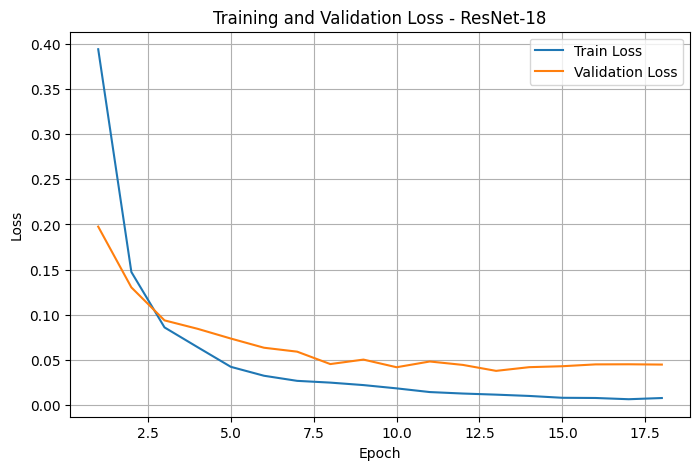

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - ResNet-18")
plt.legend()
plt.grid(True)
plt.show()

## Cell 14: Vẽ biểu đồ Macro F1

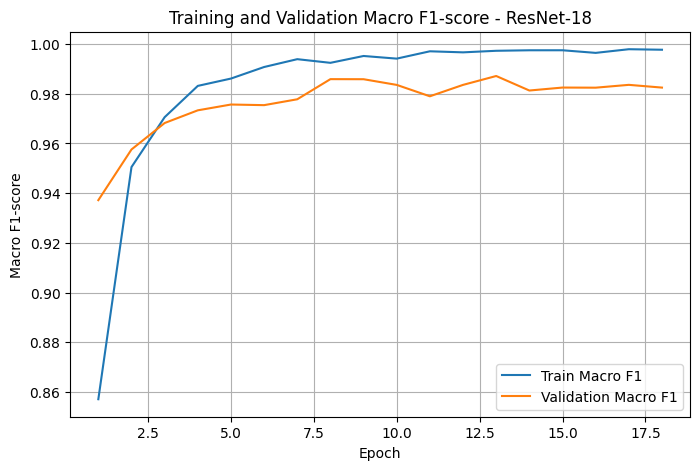

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1_macro"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_f1_macro"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Training and Validation Macro F1-score - ResNet-18")
plt.legend()
plt.grid(True)
plt.show()

## Cell 15: Load best model

In [19]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

best_model = create_resnet18(
    num_classes=checkpoint.get("num_classes", NUM_CLASSES),
    pretrained=False
)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Loaded best model from:", SAVE_PATH)
print("Best epoch:", checkpoint["epoch"])
print("Best validation Macro F1:", checkpoint["best_val_f1"])

Using random initialization.
Loaded best model from: /kaggle/working/resnet18_brain_tumor_best.pth
Best epoch: 13
Best validation Macro F1: 0.9871303118644157


## Cell 16: Evaluation trên tập test

In [20]:
test_loss, test_acc, test_precision, test_recall, test_f1, y_true, y_pred = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Results")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall: {test_recall:.4f}")
print(f"Macro F1-score: {test_f1:.4f}")

Test Results
----------------------------------------
Test Loss: 0.3352
Accuracy: 0.9469
Macro Precision: 0.9504
Macro Recall: 0.9469
Macro F1-score: 0.9457


## Cell 17: Classification report chi tiết từng lớp

In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      glioma     0.9939    0.8175    0.8971       400
  meningioma     0.9087    0.9700    0.9383       400
     notumor     0.9091    1.0000    0.9524       400
   pituitary     0.9901    1.0000    0.9950       400

    accuracy                         0.9469      1600
   macro avg     0.9504    0.9469    0.9457      1600
weighted avg     0.9504    0.9469    0.9457      1600



## Cell 18: Confusion Matrix

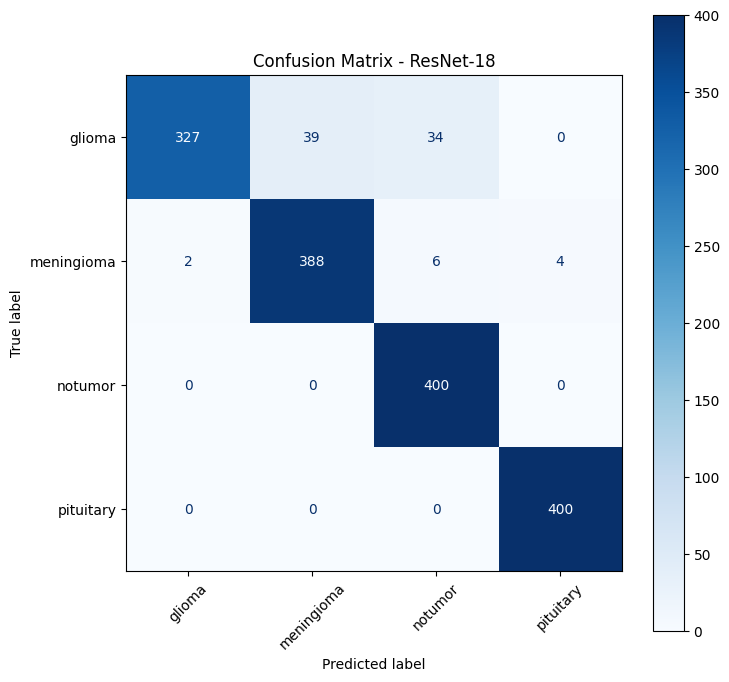

In [32]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - ResNet-18")
plt.xticks(rotation=45)
plt.show()

## Cell 19: Lưu kết quả evaluation ra CSV

In [23]:
results = {
    "model": [MODEL_NAME],
    "test_loss": [test_loss],
    "accuracy": [test_acc],
    "macro_precision": [test_precision],
    "macro_recall": [test_recall],
    "macro_f1": [test_f1],
    "best_epoch": [checkpoint["epoch"]],
    "best_val_f1": [checkpoint["best_val_f1"]]
}

results_df = pd.DataFrame(results)
results_csv_path = "/kaggle/working/resnet18_test_results.csv"
results_df.to_csv(results_csv_path, index=False)
results_df

,model,test_loss,accuracy,macro_precision,macro_recall,macro_f1,best_epoch,best_val_f1
0,resnet18,0.335214,0.946875,0.950444,0.946875,0.945714,13,0.98713


## Cell 20: Đo số tham số

In [24]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(best_model)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params / 1e6:.3f} M")

Total parameters: 11,178,564
Trainable parameters: 11,178,564
Total parameters: 11.179 M


## Cell 21: Đo dung lượng file model `.pth`

In [25]:
model_size_bytes = os.path.getsize(SAVE_PATH)
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"Model file size: {model_size_mb:.2f} MB")

Model file size: 128.06 MB


## Cell 22: Đo MACs / FLOPs

In [26]:
best_model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

macs, params = profile(
    best_model,
    inputs=(dummy_input,),
    verbose=False
)

gmacs = macs / 1e9
gflops = (2 * macs) / 1e9
params_m = params / 1e6

print(f"MACs: {gmacs:.3f} GMACs")
print(f"Approx FLOPs: {gflops:.3f} GFLOPs")
print(f"Parameters from THOP: {params_m:.3f} M")

MACs: 1.824 GMACs
Approx FLOPs: 3.647 GFLOPs
Parameters from THOP: 11.179 M


## Cell 23: Đo latency và throughput

In [27]:
def measure_latency(model, device, input_size=(1, 3, 224, 224), warmup=50, runs=200):
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        for _ in range(runs):
            _ = model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.time()

    avg_latency_sec = (end_time - start_time) / runs
    avg_latency_ms = avg_latency_sec * 1000
    throughput = 1000 / avg_latency_ms

    return avg_latency_ms, throughput

latency_ms, throughput = measure_latency(
    best_model,
    device,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    warmup=50,
    runs=200
)

print(f"Average latency: {latency_ms:.3f} ms/image")
print(f"Throughput: {throughput:.2f} images/second")

Average latency: 2.259 ms/image
Throughput: 442.66 images/second


## Cell 24: Đo peak GPU memory

In [28]:
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    best_model.eval()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

    with torch.no_grad():
        _ = best_model(dummy_input)

    peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"Peak GPU memory: {peak_memory_mb:.2f} MB")
else:
    peak_memory_mb = None
    print("CUDA is not available. GPU memory measurement skipped.")

Peak GPU memory: 392.59 MB


## Cell 25: Tổng hợp kết quả hiệu suất tính toán

In [29]:
efficiency_results = {
    "model": MODEL_NAME,
    "input_size": f"{IMG_SIZE}x{IMG_SIZE}",
    "parameters_M": total_params / 1e6,
    "model_size_MB": model_size_mb,
    "MACs_G": gmacs,
    "FLOPs_G_approx": gflops,
    "latency_ms_per_image": latency_ms,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_MB": peak_memory_mb
}

efficiency_df = pd.DataFrame([efficiency_results])
efficiency_csv_path = "/kaggle/working/resnet18_efficiency_results.csv"
efficiency_df.to_csv(efficiency_csv_path, index=False)
efficiency_df

,model,input_size,parameters_M,model_size_MB,MACs_G,FLOPs_G_approx,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_MB
0,resnet18,224x224,11.178564,128.060039,1.823524,3.647048,2.25909,442.656124,392.586914


## Cell 26: Gộp kết quả phân loại và hiệu suất

In [30]:
final_results = {
    "model": MODEL_NAME,
    "accuracy": test_acc,
    "macro_precision": test_precision,
    "macro_recall": test_recall,
    "macro_f1": test_f1,
    "parameters_M": total_params / 1e6,
    "model_size_MB": model_size_mb,
    "MACs_G": gmacs,
    "FLOPs_G_approx": gflops,
    "latency_ms_per_image": latency_ms,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_MB": peak_memory_mb,
    "best_epoch": checkpoint["epoch"],
    "best_val_f1": checkpoint["best_val_f1"]
}

final_df = pd.DataFrame([final_results])
final_csv_path = "/kaggle/working/resnet18_final_results.csv"
final_df.to_csv(final_csv_path, index=False)
final_df

,model,accuracy,macro_precision,macro_recall,macro_f1,parameters_M,model_size_MB,MACs_G,FLOPs_G_approx,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_MB,best_epoch,best_val_f1
0,resnet18,0.946875,0.950444,0.946875,0.945714,11.178564,128.060039,1.823524,3.647048,2.25909,442.656124,392.586914,13,0.98713


## Cell 27: In đường dẫn các file output

In [31]:
print("Saved files:")
print("Best model:", SAVE_PATH)
print("Training history:", history_csv_path)
print("Test results:", results_csv_path)
print("Efficiency results:", efficiency_csv_path)
print("Final results:", final_csv_path)

Saved files:
Best model: /kaggle/working/resnet18_brain_tumor_best.pth
Training history: /kaggle/working/resnet18_training_history.csv
Test results: /kaggle/working/resnet18_test_results.csv
Efficiency results: /kaggle/working/resnet18_efficiency_results.csv
Final results: /kaggle/working/resnet18_final_results.csv
